# Supervised Learning: USA BMI Extremes

This notebook tests whether a microbial signature distinguishes the **tails** of the USA BMI distribution (Lean: BMI < 22, Obese: BMI > 35). The three-way Normal/Overweight/Obese contrast (`03_Tsne_USA.ipynb`) showed no t-SNE/UMAP clusters, and the main Western/non-Western contrast is handled separately. Here we ask a narrower exploratory question: **does restricting to the BMI tails reveal a within-USA signal?**

## Pipeline

1. **Random Forest** (StratifiedKFold 5, `class_weight='balanced'`) — balanced accuracy & macro-F1, MDI feature importance averaged across folds.
2. **Label-permutation test** — shuffle the labels 100 times, retrain the RF each time, compare to the real CV score. This is the *validity check*: if the real score is not extreme relative to the null distribution, the feature ranking is noise.
3. **L1 Logistic Regression** (`LogisticRegressionCV`, liblinear) — independent linear validator that the classes are separable.
4. **Top 5 RF features** with per-class mean abundance for direction.

All preprocessing (`VarianceThreshold`, `StandardScaler`) lives inside `Pipeline` objects so test folds are never touched during fitting.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import VarianceThreshold
from sklearn.linear_model import LogisticRegressionCV
from sklearn.metrics import balanced_accuracy_score, f1_score
from sklearn.model_selection import StratifiedKFold, cross_val_score, permutation_test_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42
N_PERMUTATIONS = 100
TOP_N = 5

## Load the extreme-BMI subset

In [2]:
df = pd.read_csv('../data/processed/07_extreme_bmi_data.csv')

features = [c for c in df.columns if c.startswith('msp')]
X = df[features]
y = df['BMI_Extreme'].map({'Lean': 0, 'Obese': 1})

print(f"Samples: {len(df)} | Features: {len(features)}")
print(df['BMI_Extreme'].value_counts().to_string())

Samples: 142 | Features: 596
BMI_Extreme
Lean     119
Obese     23


## Random Forest: cross-validated performance + MDI

A single `cross_val_score` call gives the per-fold balanced accuracy. We then refit the pipeline on each fold to collect MDI importances — averaging across folds is more stable than a single full-data fit.

In [3]:
rf_pipeline = Pipeline([
    ('var_filter', VarianceThreshold(threshold=0.0001)),
    ('rf', RandomForestClassifier(
        n_estimators=200,
        max_features='sqrt',
        class_weight='balanced',
        min_samples_leaf=2,
        random_state=RANDOM_STATE,
        n_jobs=1,                  # outer CV/permutation loops use n_jobs=-1 instead
    ))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

rf_bacc = cross_val_score(rf_pipeline, X, y, cv=cv, scoring='balanced_accuracy', n_jobs=-1)
rf_f1   = cross_val_score(rf_pipeline, X, y, cv=cv, scoring='f1_macro',         n_jobs=-1)

print(f"RF Balanced Accuracy: {rf_bacc.mean():.3f} +/- {rf_bacc.std()*2:.3f}")
print(f"RF Macro-F1:          {rf_f1.mean():.3f} +/- {rf_f1.std()*2:.3f}")
print(f"Per-fold balanced acc: {np.round(rf_bacc, 3)}")

RF Balanced Accuracy: 0.570 +/- 0.196
RF Macro-F1:          0.561 +/- 0.285
Per-fold balanced acc: [0.5  0.6  0.5  0.5  0.75]


In [5]:
# Collect MDI importances by refitting per fold
mdi_per_fold = []
for train_idx, _ in cv.split(X, y):
    rf_pipeline.fit(X.iloc[train_idx], y.iloc[train_idx])
    kept = X.columns[rf_pipeline.named_steps['var_filter'].get_support()]
    mdi_per_fold.append(
        pd.Series(rf_pipeline.named_steps['rf'].feature_importances_, index=kept)
    )

mdi_mean = pd.concat(mdi_per_fold, axis=1).fillna(0).mean(axis=1).sort_values(ascending=False)
print(f"Top {TOP_N} features by MDI:")
print(mdi_mean.head(TOP_N).round(4).to_string())

Top 5 features by MDI:
msp_0142    0.0243
msp_0357    0.0178
msp_1641    0.0134
msp_0196    0.0131
msp_1022    0.0126


## Validity check: label-permutation test

`permutation_test_score` shuffles `y` `N_PERMUTATIONS` times, retrains the model, and records the CV balanced accuracy each time. The p-value is the fraction of permuted runs that match or exceed the real score.

- **p < 0.05** → the RF is doing better than chance; the MDI ranking reflects real signal.
- **p ≥ 0.05** → the score is within the noise floor for this dataset; treat the top-5 features as exploratory only.

In [6]:
real_score, perm_scores, p_value = permutation_test_score(
    rf_pipeline, X, y,
    cv=cv,
    scoring='balanced_accuracy',
    n_permutations=N_PERMUTATIONS,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

print(f"Real CV balanced accuracy: {real_score:.3f}")
print(f"Permutation null mean:     {perm_scores.mean():.3f} +/- {perm_scores.std():.3f}")
print(f"p-value ({N_PERMUTATIONS} permutations): {p_value:.3f}")
print()
print("VERDICT:", "signal above noise" if p_value < 0.05 else "NOT distinguishable from noise")

Real CV balanced accuracy: 0.570
Permutation null mean:     0.498 +/- 0.020
p-value (100 permutations): 0.020

VERDICT: signal above noise


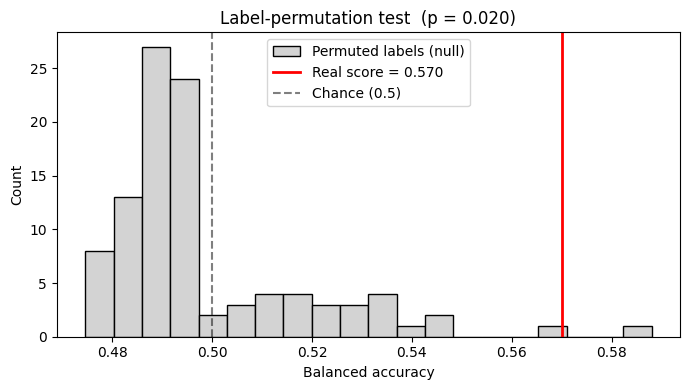

In [7]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(perm_scores, bins=20, color='lightgray', edgecolor='black', label='Permuted labels (null)')
ax.axvline(real_score, color='red', linewidth=2, label=f'Real score = {real_score:.3f}')
ax.axvline(0.5, color='black', linestyle='--', alpha=0.5, label='Chance (0.5)')
ax.set_xlabel('Balanced accuracy')
ax.set_ylabel('Count')
ax.set_title(f'Label-permutation test  (p = {p_value:.3f})')
ax.legend()
plt.tight_layout()
plt.show()

## Logistic Regression (L1) — linear validator

Independent check that the classes are linearly separable. Different model family, same CV, same metric.

In [11]:
""" lr_pipeline = Pipeline([
    ('var_filter', VarianceThreshold(threshold=0.0001)),
    ('scaler', StandardScaler()),
    ('lr', LogisticRegressionCV(
        Cs=5,
        cv=5,
        penalty='l1',
        solver='liblinear',
        scoring='balanced_accuracy',
        class_weight='balanced',
        max_iter=1000,
        random_state=RANDOM_STATE,
    ))
])

lr_bacc = cross_val_score(lr_pipeline, X, y, cv=cv, scoring='balanced_accuracy', n_jobs=-1)
lr_f1   = cross_val_score(lr_pipeline, X, y, cv=cv, scoring='f1_macro',         n_jobs=-1)

print(f"LR Balanced Accuracy: {lr_bacc.mean():.3f} +/- {lr_bacc.std()*2:.3f}")
print(f"LR Macro-F1:          {lr_f1.mean():.3f} +/- {lr_f1.std()*2:.3f}")
print(f"Per-fold balanced acc: {np.round(lr_bacc, 3)}") """

' lr_pipeline = Pipeline([\n    (\'var_filter\', VarianceThreshold(threshold=0.0001)),\n    (\'scaler\', StandardScaler()),\n    (\'lr\', LogisticRegressionCV(\n        Cs=5,\n        cv=5,\n        penalty=\'l1\',\n        solver=\'liblinear\',\n        scoring=\'balanced_accuracy\',\n        class_weight=\'balanced\',\n        max_iter=1000,\n        random_state=RANDOM_STATE,\n    ))\n])\n\nlr_bacc = cross_val_score(lr_pipeline, X, y, cv=cv, scoring=\'balanced_accuracy\', n_jobs=-1)\nlr_f1   = cross_val_score(lr_pipeline, X, y, cv=cv, scoring=\'f1_macro\',         n_jobs=-1)\n\nprint(f"LR Balanced Accuracy: {lr_bacc.mean():.3f} +/- {lr_bacc.std()*2:.3f}")\nprint(f"LR Macro-F1:          {lr_f1.mean():.3f} +/- {lr_f1.std()*2:.3f}")\nprint(f"Per-fold balanced acc: {np.round(lr_bacc, 3)}") '

## Top 5 RF features

Mean abundance per class is shown so each feature has a direction (higher in Lean vs. higher in Obese). Whether to *trust* this list depends on the permutation-test p-value above.

In [12]:
top5 = mdi_mean.head(TOP_N).index.tolist()

summary = pd.DataFrame({
    'Microbe': top5,
    'MDI_Importance': mdi_mean.loc[top5].values,
    'Mean_Lean':  X.loc[y == 0, top5].mean().values,
    'Mean_Obese': X.loc[y == 1, top5].mean().values,
})
summary['Enriched_In'] = np.where(
    summary['Mean_Obese'] > summary['Mean_Lean'], 'Obese', 'Lean'
)

print(summary.to_string(index=False, float_format=lambda x: f'{x:+.4f}'))
print()
print(f"RF permutation-test p-value: {p_value:.3f}  "
      f"({'trust the ranking' if p_value < 0.05 else 'EXPLORATORY ONLY -- within noise'})")

import os
os.makedirs('../results', exist_ok=True)
summary.to_csv('../results/biomarker_top5_rf_bmi_extremes.csv', index=False)
print("\nSaved: ../results/biomarker_top5_rf_bmi_extremes.csv")

 Microbe  MDI_Importance  Mean_Lean  Mean_Obese Enriched_In
msp_0142         +0.0243    +2.0004     +4.5843       Obese
msp_0357         +0.0178    -0.3037     +2.6408       Obese
msp_1641         +0.0134    +1.6774     +3.6516       Obese
msp_0196         +0.0131    +4.8757     +1.7853        Lean
msp_1022         +0.0126    -0.9822     -2.0762        Lean

RF permutation-test p-value: 0.020  (trust the ranking)

Saved: ../results/biomarker_top5_rf_bmi_extremes.csv


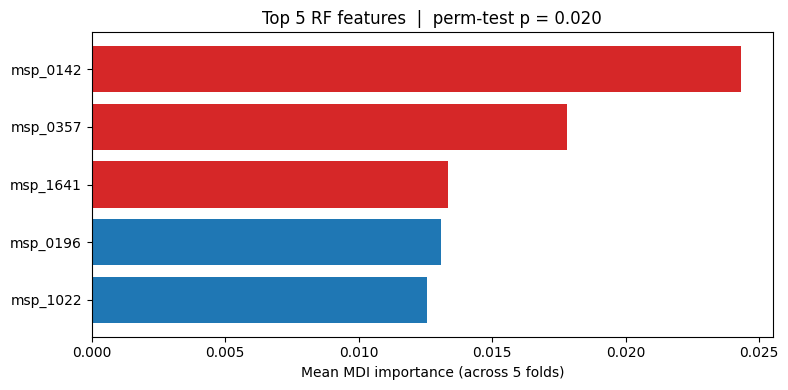

In [13]:
# Visualize top 5
fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#d62728' if e == 'Obese' else '#1f77b4' for e in summary['Enriched_In']]
ax.barh(summary['Microbe'][::-1], summary['MDI_Importance'][::-1], color=colors[::-1])
ax.set_xlabel('Mean MDI importance (across 5 folds)')
ax.set_title(f'Top {TOP_N} RF features  |  perm-test p = {p_value:.3f}')
plt.tight_layout()
plt.show()

# Analysis Summary: Microbial Signatures in Extreme BMI Groups

## 1. Model & Rationale
A **Random Forest (RF)** classifier was used to identify microbial signatures distinguishing **Lean (BMI < 22)** vs. **Obese (BMI > 35)** individuals in the USA cohort. Supervised learning focuses on discriminative signals from individual species, which is necessary given the high interpersonal variability in microbiome data (shared taxa often vary by an order of magnitude in abundance).

## 2. Key Performance Metrics

| Metric | Value | Interpretation |
| :--- | :--- | :--- |
| **Balanced Accuracy** | 0.570 | Modest signal above chance (0.50 = random) |
| **Permutation Test** | p = 0.020 (n = 100) | Only 2/100 shuffles matched performance → **statistically significant** |

## 3. Caveats: Signal Fragility
**Stratified 5-Fold CV scores:** `[0.50, 0.60, 0.50, 0.50, 0.75]`

- **Small sample size:** Obese subgroup has only *n = 23* (~4–5 samples per test fold).
- **High variance:** Three folds at chance, one strong fold (0.75) suggests the signature exists in specific sub-populations rather than uniformly. The signal is **real but fragile**.

## 4. Top Microbial Features (CLR-transformed)

| Feature (MSP) | Association | Notes |
| :--- | :--- | :--- |
| **msp_0142** | Obese | Highest importance (MDI 0.024) |
| **msp_0357** | Obese | Cleanest signal: negative (Lean) → positive (Obese) |
| **msp_1641** | Obese | Enriched in high-BMI samples |
| **msp_0196** | Lean | Strongest Lean indicator |
| **msp_1022** | Lean | Consistently lower in Obese |

> **CLR note:** Values are *relative* to the geometric mean of species in each sample — positive ≠ "present," negative ≠ "absent."

## 5. Conclusion
The analysis reveals a **statistically significant but weak** microbial signature for extreme BMI (*p = 0.020*). Candidates like `msp_0142` and `msp_0357` warrant further investigation as metabolic biomarkers, but the signal is too fragile for clinical use. Larger cohorts are needed to stabilize these findings.

Note on Class Imbalance: To ensure the results were not skewed by the majority "Lean" group, Balanced Accuracy was used, which treats both groups with equal weight; this forces the random "shuffled" model (gray bars) to land at a baseline of 0.50 regardless of the group sizes.